In [107]:
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

In [108]:
dataset = load_iris()

In [176]:
x = dataset.data
y = dataset.target

In [110]:
dataset.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

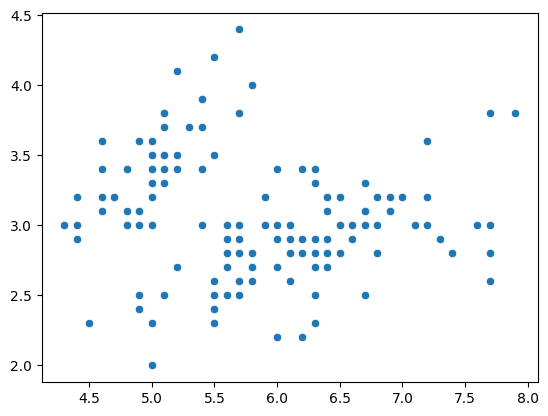

In [111]:
sns.scatterplot(x=x[:,0],y=x[:,1])
plt.show()

In [282]:
class k_means:
    def __init__(self,k):
        self.k = k
        self.x_train = []
        self.centroid = []
        self.cluster = []

    def e_distance(self,x,centroid):
        return np.sqrt(np.sum((x-centroid)**2))
    
    def fit(self,x_train,new_cluster=None,centroid=None):
        self.x_train = x_train
        cluster = list()
        if centroid is None:
            centroid = random.sample(list(x_train), self.k)
            centroid = [np.array(c) for c in centroid]
        if new_cluster is None:
            new_cluster = []
        for i in x_train:
            distnce = []
            for j in range(1,len(centroid)+1):
                distnce.append((self.e_distance(i,centroid[j-1]),j))
            cluster.append((min(distnce)[1]))
        if cluster == new_cluster:
            self.centroid = centroid
            self.cluster = cluster
            return centroid,cluster
        new_centroid = []
        for k in range(1,self.k+1):
            points = [x_train[i] for i in range(len(x_train)) if cluster[i] == k]

            if len(points) == 0:  # avoid empty cluster
                new_centroid.append(centroid[k-1])
            else:
                new_centroid.append(np.mean(points, axis=0))
        return self.fit(x_train,cluster,new_centroid)
        
    def wcss(self):
        wcss = 0
        for i in range(len(self.x_train)):
    
            assigned_cluster = self.cluster[i] - 1
            point = self.x_train[i]
            center = self.centroid[assigned_cluster]
    
            wcss += np.sum((point - center) ** 2)
    
        return wcss

In [314]:
km = k_means(3)
km.fit(x)
km.wcss()

np.float64(78.85566582597724)

In [316]:
km.centroid

[array([6.85384615, 3.07692308, 5.71538462, 2.05384615]),
 array([5.006, 3.428, 1.462, 0.246]),
 array([5.88360656, 2.74098361, 4.38852459, 1.43442623])]

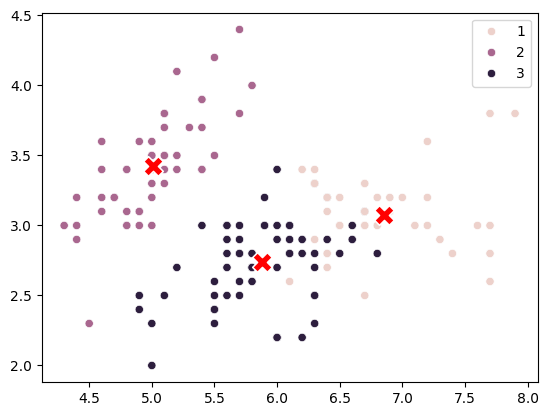

In [319]:
sns.scatterplot(x=x[:,0],y=x[:,1],hue=km.cluster)
sns.scatterplot(
    x=np.array(km.centroid)[:, 0],
    y=np.array(km.centroid)[:, 1],
    marker="X",
    s=200,
    color="red"
)
plt.show()

In [294]:
_x = list()
_y = list()

In [307]:
for k1 in range(1,10):
    kn1 = k_means(k1)
    kn1.fit(x)
    _x.append(k1)
    _y.append(kn1.wcss())

In [308]:
# sns.scatterplot(x=x[:,0],y=x[:,1],hue=c[1])
# plt.show()

In [311]:
# _x,_y

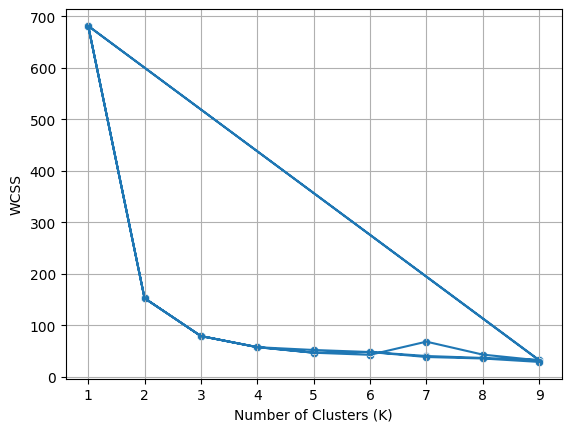

In [310]:
sns.scatterplot(x=_x,y=_y)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.plot(_x,_y)
plt.grid()
plt.show()